In [1]:

from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import TCT

import matplotlib.pyplot as plt
import requests

In [2]:
Translator_KP_info, APInames = translator_kpinfo.get_translator_kp_info()
metaKG = translator_metakg.get_KP_metadata(APInames)
  
APInames, metaKG = translator_metakg.add_plover_API(APInames, metaKG)

Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
Skipping server without x-maturity: {'url': '/sipr'}


In [3]:
set(Translator_KP_info['title'])

{'ARAX Translator Reasoner - TRAPI 1.6.0',
 'Answer-coalesce(Trapi v1.5.0)',
 'Aragorn(Trapi v1.5.0)',
 'Aragorn(Trapi v1.6.0)',
 'Automat-binding-db(Trapi v1.5.0)',
 'Automat-cam-kp(Trapi v1.5.0)',
 'Automat-ctd(Trapi v1.5.0)',
 'Automat-drug-central(Trapi v1.5.0)',
 'Automat-ehr-clinical-connections-kp(Trapi v1.5.0)',
 'Automat-ehr-may-treat-kp(Trapi v1.5.0)',
 'Automat-genome-alliance(Trapi v1.5.0)',
 'Automat-gtex(Trapi v1.5.0)',
 'Automat-gtopdb(Trapi v1.5.0)',
 'Automat-gwas-catalog(Trapi v1.5.0)',
 'Automat-hetionet(Trapi v1.5.0)',
 'Automat-hgnc(Trapi v1.5.0)',
 'Automat-hmdb(Trapi v1.5.0)',
 'Automat-human-goa(Trapi v1.5.0)',
 'Automat-icees-kg(Trapi v1.5.0)',
 'Automat-intact(Trapi v1.5.0)',
 'Automat-monarchinitiative(Trapi v1.5.0)',
 'Automat-panther(Trapi v1.5.0)',
 'Automat-pharos(Trapi v1.5.0)',
 'Automat-reactome(Trapi v1.5.0)',
 'Automat-robokop(Trapi v1.5.0)',
 'Automat-string-db(Trapi v1.5.0)',
 'Automat-ubergraph(Trapi v1.5.0)',
 'Automat-viral-proteome(Trapi v1.5.0

In [4]:
Translator_KP_info.loc[Translator_KP_info['title'] == 'Retriever']

,id,title,prod_url,ci_url,test_url
22,https://smart-api.info/ui/7a12feb2fbd8fe4af532...,Retriever,None,https://retriever.ci.transltr.io/query/,None


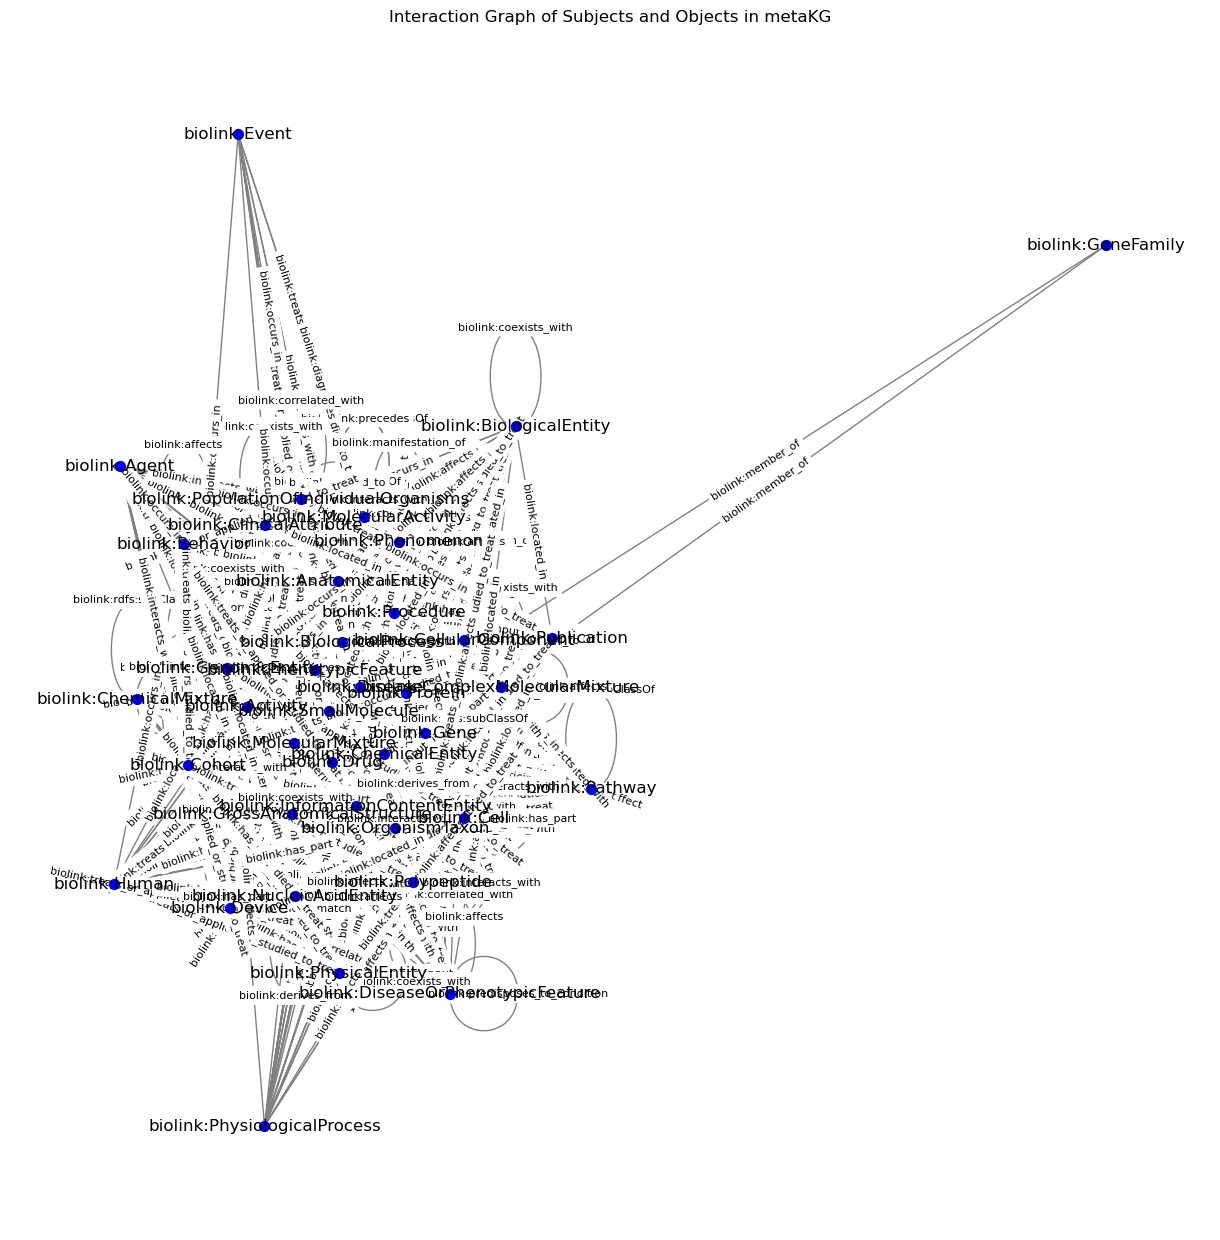

In [5]:
import networkx as nx
selected_KGs = ['Retriever']

metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]
#metaKG_sele = metaKG_sele[metaKG_sele['Subject'] == 'biolink:OrganismTaxon' ] # remove the generic predicate to make the graph more interpretable
# build a multigraph to capture all edges (including duplicates) and their predicates
G = nx.MultiGraph()
for _, row in metaKG_sele.iterrows():
        G.add_edge(row['Subject'], row['Object'], predicate=row['Predicate'])

# layout and draw nodes + edges
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, iterations=20)
nx.draw(G, pos,
                with_labels=True,
                node_size=50,
                font_size=12,
                font_color='black',
                node_color='blue',
                edge_color='gray')

# draw edge labels
edge_labels = nx.get_edge_attributes(G, 'predicate')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Interaction Graph of Subjects and Objects in metaKG')
plt.show()

In [17]:
print(len(set(metaKG_sele['Subject'].tolist() + metaKG_sele['Object'].tolist())))

38


In [9]:
len(set(metaKG_sele['Predicate']))

45

In [11]:
metaKG[['Predicate','Subject','Object']].drop_duplicates()

,Predicate,Subject,Object
0,biolink:treated_by,biolink:PhenotypicFeature,biolink:MolecularMixture
1,biolink:treated_by,biolink:PhenotypicFeature,biolink:ChemicalEntity
2,biolink:associated_with,biolink:ChemicalEntity,biolink:Gene
3,biolink:treated_by,biolink:Disease,biolink:MolecularMixture
4,biolink:treated_by,biolink:Disease,biolink:ChemicalEntity
...,...,...,...
24035,biolink:applied_to_treat,biolink:NamedThing,biolink:Disease
24036,biolink:applied_to_treat,biolink:NamedThing,biolink:PhenotypicFeature
24037,biolink:applied_to_treat,biolink:NamedThing,biolink:BehavioralFeature
24038,biolink:applied_to_treat,biolink:ChemicalEntity,biolink:BehavioralFeature
